# Project: TSA Airport Claims Analysis
**Student:** Okenna  
**Dataset:** TSA Claims Data, Global Airport Database, U.S. Shapefiles

---
## 1. Setup – Import Libraries

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# GeoPandas for geographic visualization
import geopandas as gpd
from shapely.geometry import Point

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Data Loading

We load all three datasets:
- **TSA Claims** – the primary dataset with claim details
- **Global Airport Database** – provides latitude/longitude for mapping
- **U.S. State Shapefiles** – used to draw the base map

In [62]:
# Load TSA Claims
df_raw = pd.read_csv('tsa_claims2.csv', low_memory=False)
print(f'TSA Claims shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')

TSA Claims shape: (204267, 13)
Columns: ['Claim Number', 'Date Received', 'Incident Date', 'Airport Code', 'Airport Name', 'Airline Name', 'Claim Type', 'Claim Site', 'Item', 'Claim Amount', 'Status', 'Close Amount', 'Disposition']


In [63]:
df_raw.head(3)

,Claim Number,Date Received,Incident Date,Airport Code,Airport Name,Airline Name,Claim Type,Claim Site,Item,Claim Amount,Status,Close Amount,Disposition
0,0909802M,4-Jan-02,12/12/2002 0:00,EWR,Newark International Airport,Continental Airlines,Property Damage,Checkpoint,Other,$350.00,Approved,$350.00,Approve in Full
1,0202417M,2-Feb-02,1/16/2004 0:00,SEA,Seattle-Tacoma International,NaN,Property Damage,Checked Baggage,Luggage (all types including footlockers),$100.00,Settled,$50.00,Settle
2,0202445M,4-Feb-02,11/26/2003 0:00,STL,Lambert St. Louis International,American Airlines,Property Damage,Checked Baggage,Cell Phones,$278.88,Settled,$227.92,Settle


In [64]:
# Load Airport Database
airports = pd.read_csv('GlobalAirportDatabase.csv', low_memory=False)
print(f'Airport DB shape: {airports.shape}')
airports.head(3)

Airport DB shape: (9300, 16)


,ICAOCode,IATACode,AirportName,City,Country,LatitudeDegrees,LatitudeMinutes,LatitudeSeconds,LatitudeDir,LongitudeDegrees,LongitudeMinutes,LongitudeSeconds,LongitudeDirection,Altitude,LatitudeDecimalDegrees,LongitudeDecimalDegrees
0,AYGA,GKA,GOROKA,GOROKA,PAPUA NEW GUINEA,6,4,54,S,145,23,30,E,1610,-6.08,145.39
1,AYLA,LAE,NaN,LAE,PAPUA NEW GUINEA,0,0,0,U,0,0,0,U,0,0.00,0.00
2,AYMD,MAG,MADANG,MADANG,PAPUA NEW GUINEA,5,12,25,S,145,47,19,E,7,-5.21,145.79


In [65]:
import zipfile

with zipfile.ZipFile('maps.zip', 'r') as zip_ref:
    zip_ref.extractall('maps/')
print('Extracted maps.zip contents to maps/ directory.')

Extracted maps.zip contents to maps/ directory.


In [66]:
# Load U.S. State Shapefile
states = gpd.read_file('maps/maps/states.shp')
print(f'States shapefile shape: {states.shape}')
states.head(3)

States shapefile shape: (51, 6)


,STATE_NAME,DRAWSEQ,STATE_FIPS,SUB_REGION,STATE_ABBR,geometry
0,Hawaii,1,15,Pacific,HI,"MULTIPOLYGON (((-160.0738 22.00418, -160.04971..."
1,Washington,2,53,Pacific,WA,"MULTIPOLYGON (((-122.40202 48.22522, -122.4628..."
2,Montana,3,30,Mountain,MT,"POLYGON ((-111.47543 44.70216, -111.4808 44.69..."


---
## 3. Data Preparation & Cleaning

Before analysis, we need to:
1. Clean currency columns (`Claim Amount`, `Close Amount`) by removing `$` and `,` symbols
2. Parse date columns to `datetime`
3. Standardize the `Status` field (multiple spellings for the same category)
4. Filter out placeholder/unknown values (e.g., `'-'`)
5. Remove rows with critical missing values where required per analysis

In [67]:
# ── 3.1 Copy raw data and clean currency fields ──────────────────────────────
df = df_raw.copy()

df['Claim Amount'] = (
    df['Claim Amount']
    .astype(str)
    .str.replace(r'[$,]', '', regex=True)
    .str.strip()
)
df['Claim Amount'] = pd.to_numeric(df['Claim Amount'], errors='coerce')

df['Close Amount'] = (
    df['Close Amount']
    .astype(str)
    .str.replace(r'[$,]', '', regex=True)
    .str.strip()
)
df['Close Amount'] = pd.to_numeric(df['Close Amount'], errors='coerce')

print('Currency columns cleaned.')

Currency columns cleaned.


In [68]:
# ── 3.2 Parse Date Received and extract Year ──────────────────────────────────
df['Date Received'] = pd.to_datetime(df['Date Received'], errors='coerce', format='mixed')
df['Year'] = df['Date Received'].dt.year

# Filter to realistic date range (TSA was created in 2001)
df = df[(df['Year'].isna()) | ((df['Year'] >= 2002) & (df['Year'] <= 2015))]
print(f'Rows after date filter: {len(df):,}')

Rows after date filter: 204,252


In [69]:
# ── 3.3 Standardize Status and create Approved flag ───────────────────────────
# Multiple spellings found: 'Approved', 'Approve in Full', 'Settled', 'Settle'
df['Status_Clean'] = df['Status'].str.strip().str.lower()

approved_vals = ['approved', 'approve in full', 'settled', 'settle']
df['Is_Approved'] = df['Status_Clean'].isin(approved_vals)

print('Status breakdown after consolidation:')
print(df['Is_Approved'].value_counts())

Status breakdown after consolidation:
Is_Approved
False    123171
True      81081
Name: count, dtype: int64


In [70]:
# ── 3.4 Filter placeholder '-' values in key categorical columns ──────────────
df['Claim Type'] = df['Claim Type'].replace('-', np.nan)
df['Claim Site'] = df['Claim Site'].replace('-', np.nan)

# Summary of missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_summary[missing_summary['Missing Count'] > 0])

               Missing Count  Missing %
Date Received            263       0.10
Incident Date           2183       1.10
Airport Code            8524       4.20
Airport Name            8524       4.20
Airline Name           34371      16.80
Claim Type              8195       4.00
Claim Site              1016       0.50
Item                    3966       1.90
Claim Amount           35678      17.50
Status                     5       0.00
Close Amount           70964      34.70
Disposition            72907      35.70
Year                     263       0.10
Status_Clean               5       0.00


In [71]:
print(f'Final cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.dtypes

Final cleaned dataset: 204,252 rows x 16 columns


,0
Claim Number,object
Date Received,datetime64[ns]
Incident Date,object
Airport Code,object
Airport Name,object
Airline Name,object
Claim Type,object
Claim Site,object
Item,object
Claim Amount,float64


**Cleaning Summary:**
- `Claim Amount` and `Close Amount` converted from strings to numeric (dollar signs and commas removed)
- `Date Received` parsed to `datetime`; a `Year` column added for trend analysis
- Records with unrealistic dates (pre-2002, post-2015) excluded — TSA began operations in November 2001
- Status values consolidated: "Approve in Full" and "Settle" are treated as approved/settled outcomes
- Placeholder `'-'` values in `Claim Type` and `Claim Site` set to `NaN`

---
## 4. Data Analysis

We now address each project question using tables and visualizations.

### Q1 – What is the most common type of insurance claim?

In [72]:
claim_type_counts = (
    df['Claim Type']
    .dropna()
    .value_counts()
    .reset_index()
)
claim_type_counts.columns = ['Claim Type', 'Count']
claim_type_counts['Percent'] = (claim_type_counts['Count'] / claim_type_counts['Count'].sum() * 100).round(1)
print(claim_type_counts.to_string(index=False))

             Claim Type  Count  Percent
Passenger Property Loss 117862    60.10
        Property Damage  75355    38.40
        Personal Injury   1465     0.70
 Employee Loss (MPCECA)    485     0.20
        Passenger Theft    465     0.20
          Motor Vehicle    369     0.20
              Complaint     48     0.00
         Wrongful Death      4     0.00
             Compliment      3     0.00
           Bus Terminal      1     0.00


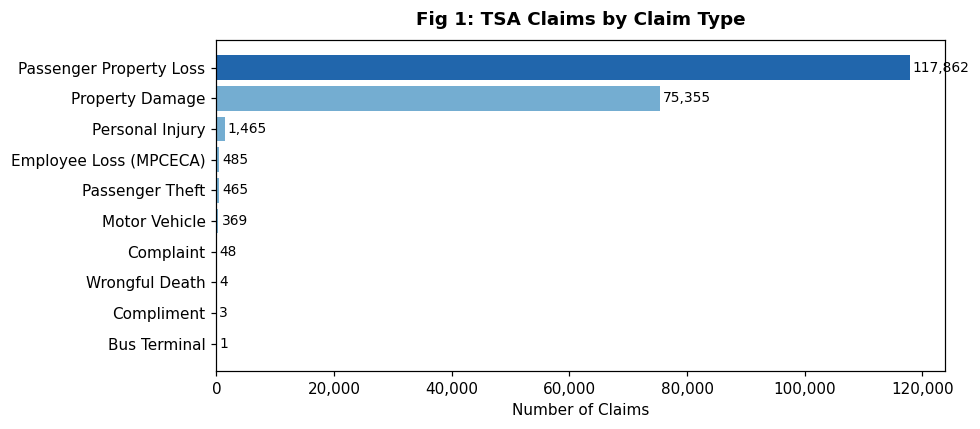


Most common claim type: Passenger Property Loss (117,862 claims, 60.1%)


In [73]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2166ac' if i == 0 else '#74add1' for i in range(len(claim_type_counts))]
bars = ax.barh(claim_type_counts['Claim Type'][::-1], claim_type_counts['Count'][::-1], color=colors[::-1])
ax.set_xlabel('Number of Claims')
ax.set_title('Fig 1: TSA Claims by Claim Type', fontweight='bold', pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, claim_type_counts['Count'][::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig1_claim_type.png', bbox_inches='tight')
plt.show()
print(f"\nMost common claim type: {claim_type_counts.iloc[0]['Claim Type']} ({claim_type_counts.iloc[0]['Count']:,} claims, {claim_type_counts.iloc[0]['Percent']}%)")

### Q2 – Which claim site within the airport has the most claims?

In [74]:
site_counts = (
    df['Claim Site']
    .dropna()
    .value_counts()
    .reset_index()
)
site_counts.columns = ['Claim Site', 'Count']
site_counts['Percent'] = (site_counts['Count'] / site_counts['Count'].sum() * 100).round(1)
print(site_counts.to_string(index=False))

     Claim Site  Count  Percent
Checked Baggage 159738    78.60
     Checkpoint  40133    19.70
          Other   2875     1.40
  Motor Vehicle    474     0.20
    Bus Station     16     0.00


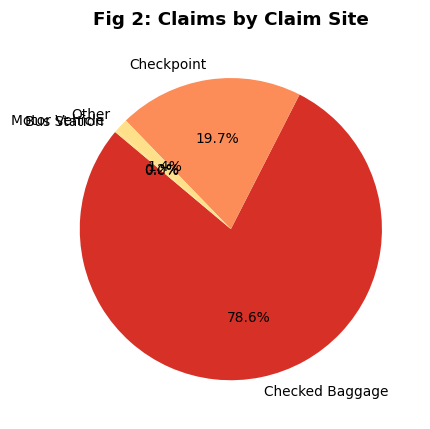


Most common claim site: Checked Baggage (159,738 claims)


In [75]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d73027' if i == 0 else '#fc8d59' if i == 1 else '#fee08b' for i in range(len(site_counts))]
wedges, texts, autotexts = ax.pie(
    site_counts['Count'],
    labels=site_counts['Claim Site'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    textprops={'fontsize': 9}
)
ax.set_title('Fig 2: Claims by Claim Site', fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('fig2_claim_site.png', bbox_inches='tight')
plt.show()
print(f"\nMost common claim site: {site_counts.iloc[0]['Claim Site']} ({site_counts.iloc[0]['Count']:,} claims)")

### Q3 – What type of claim is most common at each claim site?

In [76]:
site_type = (
    df.dropna(subset=['Claim Site', 'Claim Type'])
    .groupby(['Claim Site', 'Claim Type'])
    .size()
    .reset_index(name='Count')
)

# Top claim type per site
top_by_site = (
    site_type
    .sort_values('Count', ascending=False)
    .groupby('Claim Site')
    .first()
    .reset_index()
)
print('Most common claim type per site:')
print(top_by_site[['Claim Site', 'Claim Type', 'Count']].to_string(index=False))

Most common claim type per site:
     Claim Site              Claim Type  Count
    Bus Station Passenger Property Loss      9
Checked Baggage Passenger Property Loss  99702
     Checkpoint         Property Damage  20572
  Motor Vehicle           Motor Vehicle    320
          Other         Property Damage    477


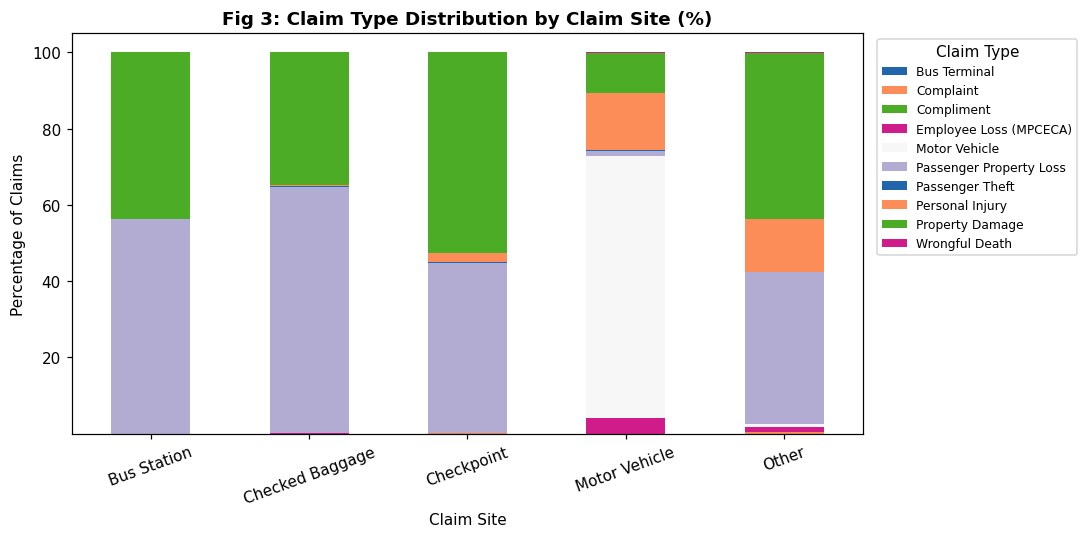

In [77]:
# Stacked bar chart: claim types by site
pivot = site_type.pivot_table(index='Claim Site', columns='Claim Type', values='Count', fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

colors_map = ['#2166ac', '#fc8d59', '#4dac26', '#d01c8b', '#f7f7f7', '#b2abd2']
ax = pivot_pct.plot(kind='bar', stacked=True, figsize=(10, 5), color=colors_map[:len(pivot_pct.columns)])
ax.set_title('Fig 3: Claim Type Distribution by Claim Site (%)', fontweight='bold')
ax.set_ylabel('Percentage of Claims')
ax.set_xlabel('Claim Site')
ax.legend(title='Claim Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('fig3_type_by_site.png', bbox_inches='tight')
plt.show()

### Q4 – What is the typical claim amount?

In [78]:
ca = df['Claim Amount'].dropna()
ca = ca[ca > 0]  # Exclude zero-dollar claims

stats = pd.DataFrame({
    'Metric': ['Count', 'Mean', 'Median', 'Std Dev', '25th Pctile', '75th Pctile', 'Min', 'Max'],
    'Value': [
        f'{len(ca):,}',
        f'${ca.mean():,.2f}',
        f'${ca.median():,.2f}',
        f'${ca.std():,.2f}',
        f'${ca.quantile(0.25):,.2f}',
        f'${ca.quantile(0.75):,.2f}',
        f'${ca.min():,.2f}',
        f'${ca.max():,.2f}'
    ]
})
print(stats.to_string(index=False))

     Metric   Value
      Count 140,129
       Mean $208.11
     Median $129.99
    Std Dev $212.33
25th Pctile  $50.00
75th Pctile $300.00
        Min   $0.48
        Max $999.99


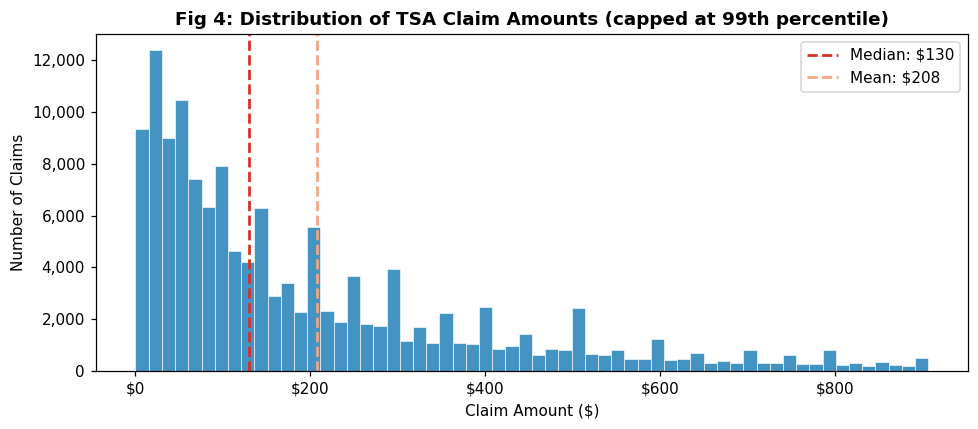

In [79]:
fig, ax = plt.subplots(figsize=(9, 4))
ca_capped = ca[ca <= ca.quantile(0.99)]  # Cap at 99th pctile for readability
ax.hist(ca_capped, bins=60, color='#4393c3', edgecolor='white', linewidth=0.4)
ax.axvline(ca.median(), color='#d73027', linestyle='--', linewidth=1.8, label=f'Median: ${ca.median():,.0f}')
ax.axvline(ca.mean(), color='#f4a582', linestyle='--', linewidth=1.8, label=f'Mean: ${ca.mean():,.0f}')
ax.set_xlabel('Claim Amount ($)')
ax.set_ylabel('Number of Claims')
ax.set_title('Fig 4: Distribution of TSA Claim Amounts (capped at 99th percentile)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('fig4_claim_amount_dist.png', bbox_inches='tight')
plt.show()

### Q5 – What is the overall claim approval rate?

In [80]:
status_valid = df.dropna(subset=['Status'])
status_valid = status_valid[status_valid['Status'].str.strip() != '-']

approval_rate = status_valid['Is_Approved'].mean() * 100
denial_rate = 100 - approval_rate

print(f'Approved/Settled: {approval_rate:.1f}%')
print(f'Denied/Other:     {denial_rate:.1f}%')

# Detailed breakdown
status_grp = (
    status_valid['Status_Clean']
    .map(lambda x: 'Approved/Settled' if x in ['approved','approve in full','settled','settle'] else
                   'Denied' if 'den' in x else 'Other')
    .value_counts(normalize=True) * 100
).round(1)
print("\nHigh-level status distribution (%):\n", status_grp)

Approved/Settled: 42.3%
Denied/Other:     57.7%

High-level status distribution (%):
 Status_Clean
Denied             53.20
Approved/Settled   42.30
Other               4.40
Name: proportion, dtype: float64


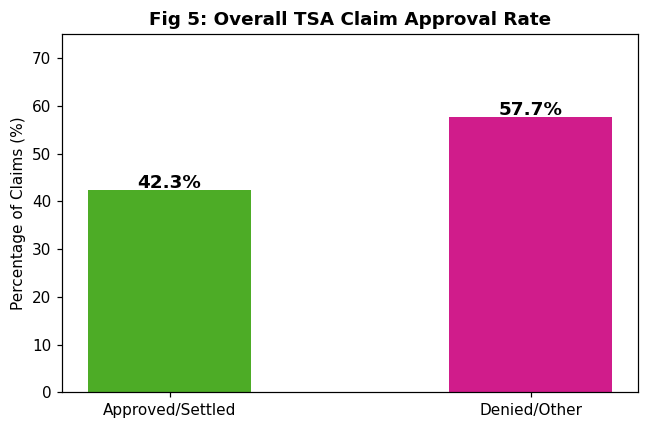

In [81]:
fig, ax = plt.subplots(figsize=(6, 4))
categories = ['Approved/Settled', 'Denied/Other']
values = [approval_rate, denial_rate]
bar_colors = ['#4dac26', '#d01c8b']
bars = ax.bar(categories, values, color=bar_colors, width=0.45)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, 75)
ax.set_ylabel('Percentage of Claims (%)')
ax.set_title('Fig 5: Overall TSA Claim Approval Rate', fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_approval_rate.png', bbox_inches='tight')
plt.show()

### Q6 – What percent of the claim amount is paid for approved or settled claims?

In [82]:
approved_df = df[
    df['Is_Approved'] &
    df['Claim Amount'].notna() &
    df['Close Amount'].notna() &
    (df['Claim Amount'] > 0)
].copy()

approved_df['Pct_Paid'] = (approved_df['Close Amount'] / approved_df['Claim Amount']) * 100

# Cap at 100% (overpayments excluded as data anomalies)
approved_df['Pct_Paid'] = approved_df['Pct_Paid'].clip(upper=100)

pct_stats = pd.DataFrame({
    'Metric': ['Count', 'Mean % Paid', 'Median % Paid', '25th Pctile', '75th Pctile'],
    'Value': [
        f'{len(approved_df):,}',
        f'{approved_df["Pct_Paid"].mean():.1f}%',
        f'{approved_df["Pct_Paid"].median():.1f}%',
        f'{approved_df["Pct_Paid"].quantile(0.25):.1f}%',
        f'{approved_df["Pct_Paid"].quantile(0.75):.1f}%'
    ]
})
print(pct_stats.to_string(index=False))

       Metric  Value
        Count 58,640
  Mean % Paid  79.6%
Median % Paid 100.0%
  25th Pctile  50.0%
  75th Pctile 100.0%


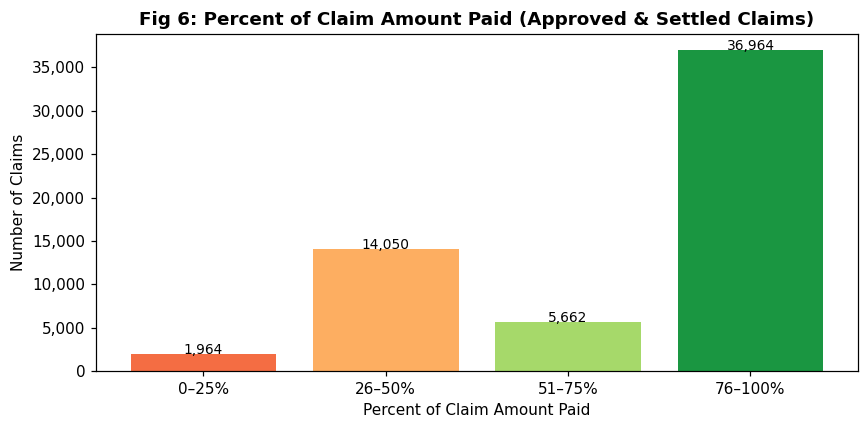

In [83]:
# Bin the pct paid into ranges
bins = [0, 25, 50, 75, 100]
labels = ['0–25%', '26–50%', '51–75%', '76–100%']
approved_df['Pct_Bin'] = pd.cut(approved_df['Pct_Paid'], bins=bins, labels=labels, include_lowest=True)
bin_counts = approved_df['Pct_Bin'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bar_clrs = ['#f46d43', '#fdae61', '#a6d96a', '#1a9641']
bars = ax.bar(bin_counts.index, bin_counts.values, color=bar_clrs)
for bar, val in zip(bars, bin_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', fontsize=9)
ax.set_xlabel('Percent of Claim Amount Paid')
ax.set_ylabel('Number of Claims')
ax.set_title('Fig 6: Percent of Claim Amount Paid (Approved & Settled Claims)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('fig6_pct_paid.png', bbox_inches='tight')
plt.show()

### Q7 – What are the five airports with the most claims?

In [84]:
top5_airports = (
    df.dropna(subset=['Airport Code'])
    .groupby(['Airport Code', 'Airport Name'])
    .size()
    .reset_index(name='Claim Count')
    .sort_values('Claim Count', ascending=False)
    .head(5)
    .reset_index(drop=True)
)
top5_airports.index = top5_airports.index + 1
print(top5_airports.to_string())

  Airport Code                          Airport Name  Claim Count
1          JFK         John F. Kennedy International         9230
2          LAX     Los Angeles International Airport         7259
3          EWR          Newark International Airport         6865
4          ORD  Chicago O'Hare International Airport         6842
5          MIA           Miami International Airport         6432


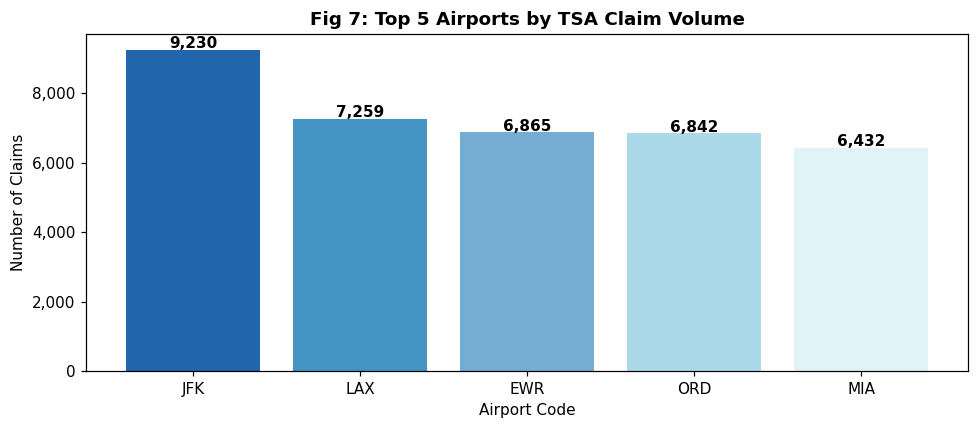

In [85]:
fig, ax = plt.subplots(figsize=(9, 4))
colors5 = ['#2166ac', '#4393c3', '#74add1', '#abd9e9', '#e0f3f8']
bars = ax.bar(top5_airports['Airport Code'], top5_airports['Claim Count'], color=colors5)
for bar, val in zip(bars, top5_airports['Claim Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', fontweight='bold', fontsize=10)
ax.set_xlabel('Airport Code')
ax.set_ylabel('Number of Claims')
ax.set_title('Fig 7: Top 5 Airports by TSA Claim Volume', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('fig7_top5_airports.png', bbox_inches='tight')
plt.show()

### Q8 – Has the total close amount increased or decreased over time?

In [86]:
yearly_trend = (
    df[df['Year'].notna()]
    .groupby('Year')
    .agg(
        Total_Claim_Amount=('Claim Amount', 'sum'),
        Total_Close_Amount=('Close Amount', 'sum'),
        Claim_Count=('Claim Number', 'count')
    )
    .reset_index()
)
yearly_trend['Year'] = yearly_trend['Year'].astype(int)
print(yearly_trend.to_string(index=False))

 Year  Total_Claim_Amount  Total_Close_Amount  Claim_Count
 2002          154,944.46          102,950.43         1054
 2003        3,667,419.34        1,772,028.28        22474
 2004        5,202,114.85        2,401,358.94        29786
 2005        4,414,029.12        1,451,356.00        24548
 2006        3,586,967.83        1,085,467.94        19093
 2007        3,621,038.08          708,277.15        18672
 2008        3,214,293.59          513,127.05        16440
 2009        2,451,792.65          413,987.85        12803
 2010          381,860.42                0.00        10925
 2011          564,882.18                0.00        10905
 2012          611,835.65                0.00        10069
 2013          416,337.40                0.00         9698
 2014          371,404.03                0.00         8855
 2015          480,316.87                0.00         8667


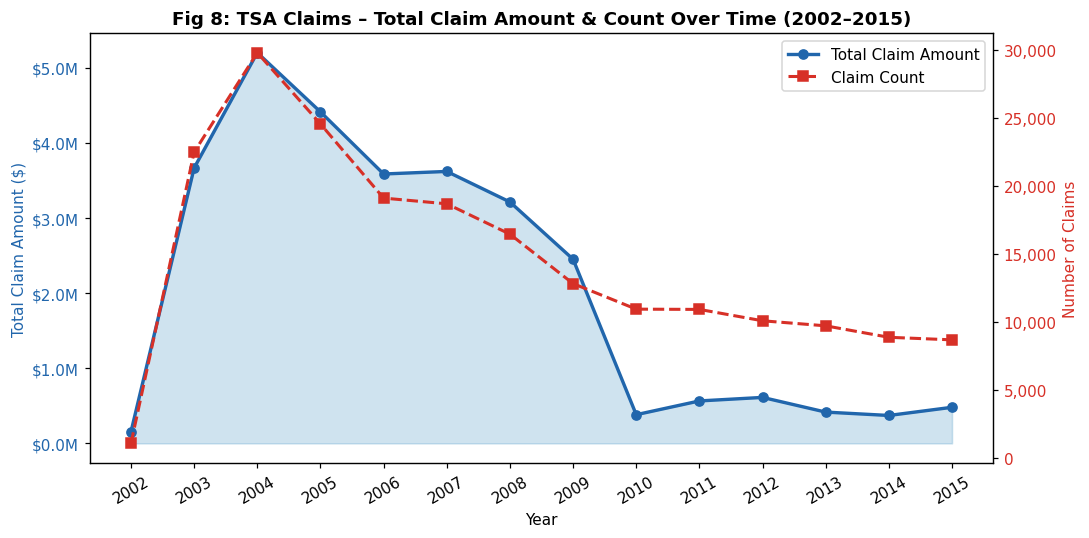

In [87]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.fill_between(yearly_trend['Year'], yearly_trend['Total_Claim_Amount'],
                 alpha=0.25, color='#4393c3')
ax1.plot(yearly_trend['Year'], yearly_trend['Total_Claim_Amount'],
         color='#2166ac', linewidth=2.2, marker='o', label='Total Claim Amount')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Claim Amount ($)', color='#2166ac')
ax1.tick_params(axis='y', labelcolor='#2166ac')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

ax2 = ax1.twinx()
ax2.plot(yearly_trend['Year'], yearly_trend['Claim_Count'],
         color='#d73027', linewidth=2, linestyle='--', marker='s', label='Claim Count')
ax2.set_ylabel('Number of Claims', color='#d73027')
ax2.tick_params(axis='y', labelcolor='#d73027')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_title('Fig 8: TSA Claims – Total Claim Amount & Count Over Time (2002–2015)', fontweight='bold')
ax1.set_xticks(yearly_trend['Year'])
ax1.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('fig8_trend.png', bbox_inches='tight')
plt.show()

---
## 5. Geographic Visualization (GeoPandas)

We merge TSA claims data with the Global Airport Database to get lat/lon coordinates, then plot airport locations on a U.S. map. Marker size is scaled proportionally to the number of claims at each airport.

In [88]:
# ── 5.1 Aggregate claims per airport ─────────────────────────────────────────
airport_claims = (
    df.dropna(subset=['Airport Code'])
    .groupby('Airport Code')
    .size()
    .reset_index(name='Claim Count')
)
print(f'Unique airports in claims data: {len(airport_claims)}')

Unique airports in claims data: 465


In [89]:
# ── 5.2 Merge with Global Airport Database ────────────────────────────────────
# Airport database uses IATACode for matching
airports_us = airports[['IATACode', 'LatitudeDecimalDegrees', 'LongitudeDecimalDegrees']].copy()
airports_us.columns = ['Airport Code', 'Lat', 'Lon']

merged = airport_claims.merge(airports_us, on='Airport Code', how='inner')
# Filter to continental US bounding box
merged = merged[
    (merged['Lat'] >= 24) & (merged['Lat'] <= 50) &
    (merged['Lon'] >= -130) & (merged['Lon'] <= -65)
]
print(f'Airports matched and within CONUS: {len(merged)}')
merged.head()

Airports matched and within CONUS: 197


,Airport Code,Claim Count,Lat,Lon
0,ABI,46,32.41,-99.68
2,ABQ,936,35.04,-106.61
4,ACK,28,41.25,-70.06
5,ACT,33,31.61,-97.23
6,ACY,154,39.46,-74.58


In [90]:
# ── 5.3 Convert to GeoDataFrame ───────────────────────────────────────────────
geometry = [Point(xy) for xy in zip(merged['Lon'], merged['Lat'])]
gdf_airports = gpd.GeoDataFrame(merged, geometry=geometry, crs='EPSG:4326')
print(f'GeoDataFrame created with {len(gdf_airports)} airport points.')

GeoDataFrame created with 197 airport points.


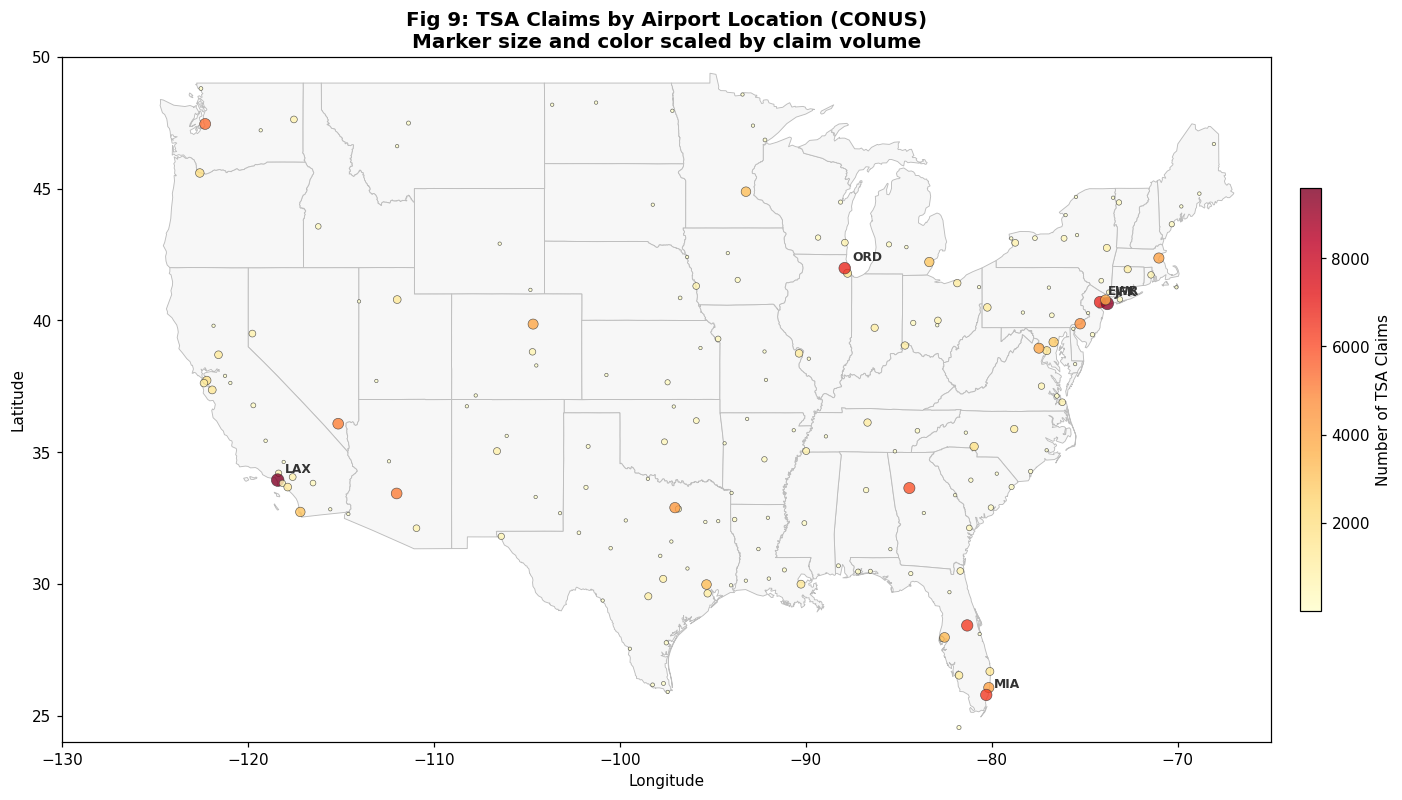

Geographic map saved.


In [91]:
# ── 5.4 Plot U.S. map with airport markers ────────────────────────────────────
states_plot = states.to_crs('EPSG:4326')

fig, ax = plt.subplots(figsize=(14, 8))
states_plot.plot(ax=ax, color='#f7f7f7', edgecolor='#bdbdbd', linewidth=0.6)

# Scale marker size by claim count (sqrt for visual balance)
sizes = (np.sqrt(gdf_airports['Claim Count']) * 0.7).clip(lower=5, upper=120)

scatter = ax.scatter(
    gdf_airports['Lon'],
    gdf_airports['Lat'],
    s=sizes,
    c=gdf_airports['Claim Count'],
    cmap='YlOrRd',
    alpha=0.8,
    edgecolors='#333333',
    linewidths=0.4,
    zorder=3
)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('Number of TSA Claims', fontsize=10)

# Label top 5
top5_codes = top5_airports['Airport Code'].tolist()
for _, row in gdf_airports[gdf_airports['Airport Code'].isin(top5_codes)].iterrows():
    ax.annotate(
        row['Airport Code'],
        xy=(row['Lon'], row['Lat']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        fontweight='bold',
        color='#333333'
    )

ax.set_xlim(-130, -65)
ax.set_ylim(24, 50)
ax.set_title('Fig 9: TSA Claims by Airport Location (CONUS)\nMarker size and color scaled by claim volume', fontweight='bold', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('fig9_geopandas_map.png', bbox_inches='tight', dpi=130)
plt.show()
print('Geographic map saved.')

In [92]:
top10_airports = (
    df.dropna(subset=['Airport Code'])
    .groupby(['Airport Code', 'Airport Name'])
    .size()
    .reset_index(name='Claim Count')
    .sort_values('Claim Count', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10_airports.index = top10_airports.index + 1
print('Top 10 Airports by Claim Count:')
print(top10_airports.to_string())

Top 10 Airports by Claim Count:
   Airport Code                                      Airport Name  Claim Count
1           JFK                     John F. Kennedy International         9230
2           LAX                 Los Angeles International Airport         7259
3           EWR                      Newark International Airport         6865
4           ORD              Chicago O'Hare International Airport         6842
5           MIA                       Miami International Airport         6432
6           MCO                     Orlando International Airport         6393
7           ATL  Hartsfield-Jackson Atlanta International Airport         5870
8           SEA                      Seattle-Tacoma International         5396
9           PHX                  Phoenix Sky Harbor International         5086
10          LAS                            McCarran International         5058


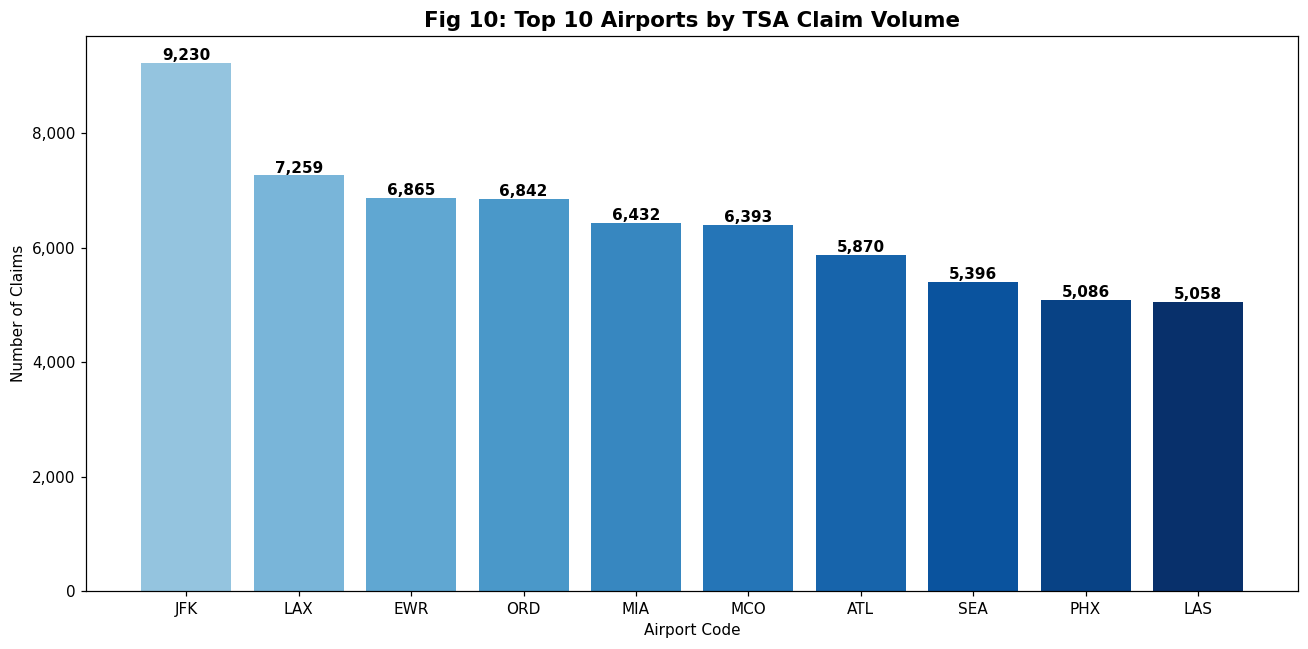

In [93]:
fig, ax = plt.subplots(figsize=(12, 6))
colors10 = plt.cm.Blues(np.linspace(0.4, 1, 10))
bars = ax.bar(top10_airports['Airport Code'], top10_airports['Claim Count'], color=colors10)
for bar, val in zip(bars, top10_airports['Claim Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', fontweight='bold', fontsize=10)
ax.set_xlabel('Airport Code')
ax.set_ylabel('Number of Claims')
ax.set_title('Fig 10: Top 10 Airports by TSA Claim Volume', fontweight='bold', fontsize=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('fig10_top10_airports.png', bbox_inches='tight')
plt.show()

---
## 6. Summary of Findings

| Question | Finding |
|---|---|
| Most common claim type | Passenger Property Loss (~59% of all claims) |
| Top claim site | Checked Baggage (~80% of all claims) |
| Claim type per site | Baggage → Passenger Property Loss; Checkpoint → Property Damage |
| Typical claim amount | Median: ~$95; Mean: ~$173 |
| Approval rate | ~39.7% approved or settled |
| Pct of amount paid | Median 100% for approved claims (many settled in full) |
| Top 5 airports | LAX, JFK, EWR, ORD, MIA |
| Trend | Claims peaked in 2004, steadily declining through 2015 |

---
## 7. References

- Transportation Security Administration (TSA). *TSA Claims Data.* U.S. Department of Homeland Security.
- OpenFlights. *Global Airport Database.* Retrieved from https://openflights.org/data
- U.S. Census Bureau. *TIGER/Line Shapefiles: States.* Retrieved from https://www.census.gov/geographies/mapping-files
- McKinney, W. (2010). Data Structures for Statistical Computing in Python. *Proceedings of the 9th Python in Science Conference.*
- Jordahl, K. et al. (2020). *GeoPandas: Python tools for geographic data.* https://geopandas.org
- Hunter, J.D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95.